# Phase 4 : Modèles Supervisés — Régression

Ce notebook se concentre sur la Phase 4 du projet d'ingénierie ML pour l'E-commerce. L'objectif est de prédire des valeurs continues, principalement le montant des transactions (CA) après transformation logarithmique.

## Objectifs :
- Prédire des valeurs continues (`log_Montant_TTC`).
- Comparer plusieurs algorithmes de régression.
- Analyser les erreurs et l'importance des variables.
- Optimiser le meilleur modèle via le réglage des hyperparamètres.

## 1. Importation des Bibliothèques et Chargement des Données

In [1]:
!pip install xgboost


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

# Configuration style
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings('ignore')

In [5]:
# Chargement du dataset enrichi
data_path = r'../data/processed/dataset_ml_features.csv'
df = pd.read_csv(data_path)

print(f"Shape du dataset : {df.shape}")
df.head()

Shape du dataset : (385, 29)


,FK_Date,Montant_TTC,Montant_HT,Mois_sin,Segment_Client,client_ca_moyen,client_nb_achats,log_Likes,FK_Geographie,log_Prix_unitaire,...,Annee,Jour_semaine,Jour_sem_cos,FK_Produit,Tranche_Remise,Est_Q4,Mois_cos,Mois,log_Prix_concurrent,log_Montant_TTC
0,20230705,39.0,33.890000,-0.500000,0,39.000000,1.0,0.0,37,3.328268,...,2023,2,-0.222521,0,0,0,-0.866025,7,0.0,3.688879
1,20230711,64.0,54.900000,-0.500000,0,64.000000,1.0,0.0,37,3.889777,...,2023,1,0.623490,0,0,0,-0.866025,7,0.0,4.174387
2,20230712,157.0,133.049999,-0.500000,0,157.000000,1.0,0.0,37,4.844581,...,2023,2,-0.222521,0,0,0,-0.866025,7,0.0,5.062595
3,20230811,7200.0,6050.420044,-0.866025,0,7200.000000,1.0,0.0,38,3.442019,...,2023,4,-0.900969,0,0,0,-0.500000,8,0.0,8.881975
4,20230811,7200.0,6050.420166,-0.866025,2,9408.802185,5.0,0.0,0,0.000000,...,2023,4,-0.900969,0,0,0,-0.500000,8,0.0,8.881975


## 2. Préparation des Données (X/y Split)

Nous devons séparer les variables explicatives (Features) de la variable cible (Target). 
- **Target** : `log_Montant_TTC` (Utilisé pour réduire l'asymétrie).
- **Variables à exclure** : `FK_Date` (temporel), `Montant_TTC` et `Montant_HT` (leaks directs du target).

In [6]:
# Sélection du target
target = 'log_Montant_TTC'

# Exclusion des colonnes non prédictives ou fuyantes (leaks)
cols_to_drop = ['FK_Date', 'Montant_TTC', 'Montant_HT', target]

# Features (X)
X = df.drop(columns=cols_to_drop)
# Target (y)
y = df[target]

print(f"Nombre de features : {X.shape[1]}")
print(f"Features utilisées : {X.columns.tolist()}")

Nombre de features : 25
Features utilisées : ['Mois_sin', 'Segment_Client', 'client_ca_moyen', 'client_nb_achats', 'log_Likes', 'FK_Geographie', 'log_Prix_unitaire', 'Est_Ete', 'Semaine', 'Jour', 'log_Quantite', 'A_Remise', 'Est_Debut_Mois', 'Jour_sem_sin', 'FK_Client', 'Likes_roll4w', 'Annee', 'Jour_semaine', 'Jour_sem_cos', 'FK_Produit', 'Tranche_Remise', 'Est_Q4', 'Mois_cos', 'Mois', 'log_Prix_concurrent']


In [7]:
# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille Train set : {X_train.shape}")
print(f"Taille Test set : {X_test.shape}")

Taille Train set : (308, 25)
Taille Test set : (77, 25)


## 3. Modèles de Base : Régression Linéaire, Ridge et Lasso

### 3.1 Régression Linéaire Standard
C'est notre modèle de référence. On cherche à minimiser la somme des carrés des résidus.

In [8]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Résultats Régression Linéaire :")
print(f"MAE  : {mae_lr:.4f}")
print(f"RMSE : {rmse_lr:.4f}")
print(f"R²   : {r2_lr:.4f}")

Résultats Régression Linéaire :
MAE  : 1.1145
RMSE : 1.6307
R²   : 0.3695


### 3.2 Ridge & Lasso (Régularisation)
- **Ridge (L2)** : Ajoute une pénalité au carré des coefficients pour éviter le sur-apprentissage.
- **Lasso (L1)** : Peut réduire certains coefficients à zéro, agissant ainsi comme une sélection de variables.

In [9]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

print(f"R² Ridge : {r2_score(y_test, y_pred_ridge):.4f}")
print(f"R² Lasso : {r2_score(y_test, y_pred_lasso):.4f}")

R² Ridge : 0.3713
R² Lasso : 0.3796


## 4. Modèles Non-Linéaires : Random Forest & XGBoost

### 4.1 Random Forest Regressor
Modèle basé sur le Bagging (Bootstrap Aggregating) de multiples arbres de décision.

In [10]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
print(f"R² Random Forest : {r2_rf:.4f}")

R² Random Forest : 0.7579


### 4.2 XGBoost Regressor
Modèle basé sur le Boosting, où chaque nouvel arbre tente de corriger les erreurs des précédents.

In [11]:
xg_reg = xgb.XGBRegressor(objective ='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=5)
xg_reg.fit(X_train, y_train)

y_pred_xgb = xg_reg.predict(X_test)

r2_xgb = r2_score(y_test, y_pred_xgb)
print(f"R² XGBoost : {r2_xgb:.4f}")

R² XGBoost : 0.6822


## 5. Comparaison et Évaluation des Modèles

In [12]:
models = {
    'Linear Regression': y_pred_lr,
    'Ridge': y_pred_ridge,
    'Lasso': y_pred_lasso,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb
}

results = []
for name, pred in models.items():
    results.append({
        'Modèle': name,
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        'R²': r2_score(y_test, pred)
    })

df_results = pd.DataFrame(results).sort_values(by='R²', ascending=False)
df_results

,Modèle,MAE,RMSE,R²
3,Random Forest,0.396129,1.010534,0.757877
4,XGBoost,0.384204,1.157792,0.682170
2,Lasso,1.105446,1.617551,0.379631
1,Ridge,1.112679,1.628324,0.371340
0,Linear Regression,1.114530,1.630663,0.369532


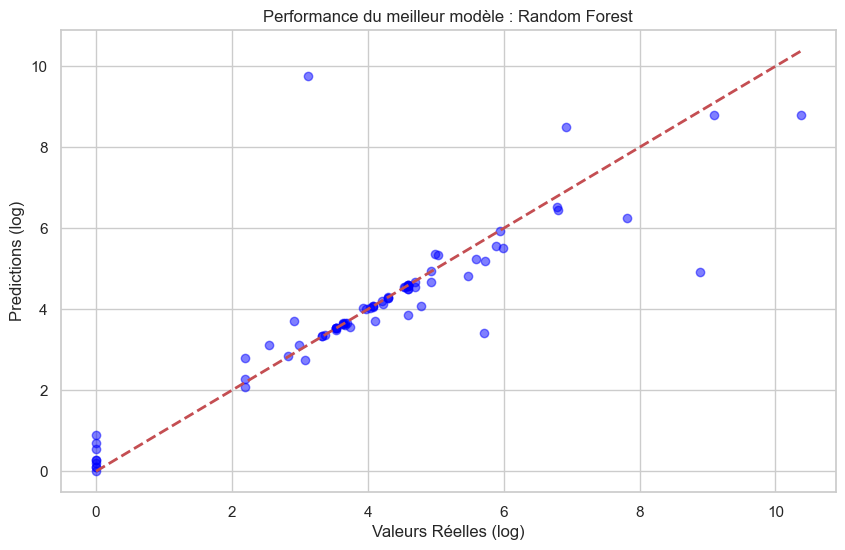

In [13]:
# Visualisation de la performance (Actual vs Predicted pour le meilleur modèle)
best_model_name = df_results.iloc[0]['Modèle']
best_preds = models[best_model_name]

plt.figure(figsize=(10, 6))
plt.scatter(y_test, best_preds, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valeurs Réelles (log)')
plt.ylabel('Predictions (log)')
plt.title(f'Performance du meilleur modèle : {best_model_name}')
plt.show()

## 6. Optimisation des Hyperparamètres (Grid Search / Randomized Search)

Nous allons optimiser le modèle XGBoost qui montre souvent de bonnes performances sur ce type de données.

In [14]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
random_search = RandomizedSearchCV(xgb_model, param_distributions=param_grid, n_iter=10, scoring='r2', cv=3, verbose=1, random_state=42)
random_search.fit(X_train, y_train)

print(f"Meilleurs paramètres : {random_search.best_params_}")
print(f"Meilleur score R² cross-val : {random_search.best_score_:.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Meilleurs paramètres : {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Meilleur score R² cross-val : 0.6594


## 7. Export du Modèle Final

In [15]:
best_final_model = random_search.best_estimator_

# Création du dossier models s'il n'existe pas
os.makedirs('../models', exist_ok=True)

# Sauvegarde
model_filename = '../models/regression_revenue_model.joblib'
joblib.dump(best_final_model, model_filename)

print(f"Modèle sauvegardé avec succès dans : {model_filename}")

Modèle sauvegardé avec succès dans : ../models/regression_revenue_model.joblib
